In [2]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
# import easyocr
# reader = easyocr.Reader(['id', 'en'], gpu=True)
# print("OK")

OK


In [39]:
import cv2
import easyocr
import re

import matplotlib.pyplot as plt

In [40]:
reader = easyocr.Reader(['id', 'en'], gpu=True)

img = cv2.imread("data\sample.jpg")

results = reader.readtext(img)

full_text = " ".join([res[1] for res in results])
clean_text = full_text.replace("O","0").replace("I","1")

print(clean_text)

PR0V1NS1 DK1 JAKARTA JAKARTA BARAT N1K 3171234567890123 Nama M1RA SET1AWAN TempatTgl Lahir JAKARTA, 18-02-1986 Jenis Kelamin PEREMPUAN Gol. Darah B Alamat JL. PAST1 CEPAT A7/66 RT1RW 007/008 KellDesa PEGADUNGAN Kecamatan KAL1DERES Agama 1SLAM Status Perkawinan KAW1N Pekerjaan PEGAWA1 SWASTA Kewarganegaraan WN1 JAKARTA BARAT 02-12-2012 Berlaku Hingga 22-02- 2017


In [11]:
nik = re.findall(r'\d{16}', clean_text)
nik = nik[0] if nik else None

In [45]:
import cv2

def preprocess(image_path):


    img = cv2.imread(image_path)

    if img is None:
        raise ValueError("Image not found")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # blur ringan saja
    blur = cv2.GaussianBlur(gray, (3,3), 0)

    return blur

In [27]:
def run_ocr(image):
    results = reader.readtext(image)
    text = " ".join([r[1] for r in results])
    return text

In [49]:
def clean_for_nik(text):
    import re

    # ambil hanya angka
    numbers = re.findall(r'\d{16}', text)

    return numbers[0] if numbers else None

In [ ]:
def clean_text(text):
    text = text.upper()

    fixes = {
        "TEMPATTGL": "TEMPAT TGL",
        "RTIRW": "RT RW",
        "KELLDESA": "KEL/DESA",
        "1SLAM": "ISLAM",
        "KAL1DERES": "KALIDERES"
    }

    for k, v in fixes.items():
        text = text.replace(k, v)

    return text

In [30]:
import re

def extract_nik(text):
    nik = re.findall(r'\d{16}', text)
    return nik[0] if nik else None

In [31]:
def extract_nama(text):
    words = text.split()

    for i, word in enumerate(words):
        if "NAMA" in word:
            # ambil 2–4 kata setelahnya
            candidate = " ".join(words[i+1:i+5])

            # filter biar bukan keyword lain
            if "TEMPAT" not in candidate and "ALAMAT" not in candidate:
                return candidate

    return None

In [32]:
def extract_ttl(text):
    match = re.search(r'([A-Z\s]+),\s*(\d{2}-\d{2}-\d{4})', text)

    if match:
        return match.group(1).strip(), match.group(2)

    return None, None

In [34]:
img = preprocess("data\sample.jpg")

raw_text = run_ocr(img)
clean = clean_text(raw_text)

nik = extract_nik(clean)
nama = extract_nama(clean)
tempat, tanggal = extract_ttl(clean)

output = {
    "nik": nik,
    "nama": nama,
    "tempat_lahir": tempat,
    "tanggal_lahir": tanggal
}

print(output)

{'nik': None, 'nama': None, 'tempat_lahir': None, 'tanggal_lahir': None}


In [36]:
print("RAW TEXT:")
print(raw_text)

RAW TEXT:
+e L ~n[l?_ 242_ 2441 9 ' PROVINSI DKI JAKARTA JAKARTA BARAT NIK 3171234567890123 Nama MIRA SETIAWAN Tempat/Tol Lahlr JAXARTA, 18-02-1988 Jenis Kolamin PEREHPUAN Gol,Darah Ałamat JL PASTI CEPAT A7/68 RTIRW 007/008 KallDesa PEGADUNGAN Kecamatan KALIDERES Agama ISLAM Status Perkawłnan KAWIN Pekerjaan PEGAWAJ SWASTA Kawarganegaraan WNł JAKARTA BARAT Borlaku Hlngga 22-02-2017 02-12-2012


In [46]:
img_processed = preprocess("data/sample_ktp.jpg")

(np.float64(-0.5), np.float64(1023.5), np.float64(663.5), np.float64(-0.5))

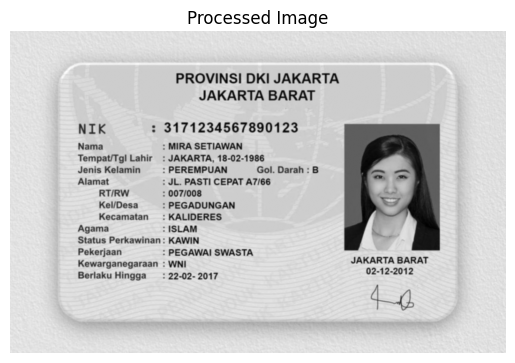

In [47]:

plt.imshow(img_processed, cmap='gray')
plt.title("Processed Image")
plt.axis('off')

In [48]:
raw_text = run_ocr(img)
print(raw_text)

PROVINSI DKI JAKARTA JAKARTA BARAT NIK 3171234567890123 Nama MIRA SETIAWAN TempatTgl Lahir JAKARTA, 18-02-1986 Jenis Kelamin PEREMPUAN Gol. Darah B Alamat JL. PASTI CEPAT A7/66 RTIRW 007/008 KellDesa PEGADUNGAN Kecamatan KALIDERES Agama ISLAM Status Perkawinan KAWIN Pekerjaan PEGAWAI SWASTA Kewarganegaraan WNI JAKARTA BARAT 02-12-2012 Berlaku Hingga 22-02- 2017


In [13]:
tgl = re.findall(r'\d{2}-\d{2}-\d{4}', clean_text)
tanggal_lahir = tgl[0] if tgl else None

In [14]:
if "LAKI" in clean_text.upper():
    jk = "Laki-laki"
elif "PEREMPUAN" in clean_text.upper():
    jk = "Perempuan"
else:
    jk = None

In [15]:
alamat_match = re.search(r'Alamat\s*[:\-]?\s*(.+)', clean_text)

alamat = alamat_match.group(1).strip() if alamat_match else None

In [18]:
output = {
    "nik": nik,
    "nama": nama,
    "tanggal_lahir": tanggal_lahir,
    "jenis_kelamin": jk,
    "alamat": alamat
}

print(output)

{'nik': '3171234567890123', 'nama': None, 'tanggal_lahir': '18-02-1986', 'jenis_kelamin': 'Perempuan', 'alamat': 'JL. PAST1 CEPAT A7/66 RT1RW 007/008 KellDesa PEGADUNGAN Kecamatan KAL1DERES Agama 1SLAM Status Perkawinan KAW1N Pekerjaan PEGAWA1 SWASTA Kewarganegaraan WN1 JAKARTA BARAT 02-12-2012 Berlaku Hingga 22-02- 2017'}
